In [1]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sentence_transformers import SentenceTransformer

from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt
from matplotlib import colors

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [20]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons, DATASETS_MAP, METHODS_MAP

In [3]:
def run_exp(
    datasets_id,
    dataset_ood,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models = ["ridge_clip","split_isotonic_on_ridge","split_isotonic_on_ridge_nrt"],
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    drop_bad_rows=True,
    verbose=False,
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    model_name = model.split("/")[-1]

    id_df = []
    for dataset in datasets_id:
        out_df, _ = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows)
        id_df.append(out_df)

    train_df = pd.concat(id_df)
    
    test_df, df_save_path = load_out_df(dataset_ood, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows)
    
    # --------------------
    # Split
    # --------------------

    X_train = stack_embeddings(train_df, "embeddings")
    y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    # These are for evaluation (your core metrics are vs correctness)
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    if verbose:
        print(f"Results: (accuracy={correct.mean():.4f})")

    # --------------------
    # Baselines (non-embedding)
    # --------------------
    def metric_row(name, scores, correct, n_bins):
        return [
            name,
            get_ece1(scores, correct, n_bins=n_bins),
            get_ece2(scores, correct, n_bins=n_bins),
            get_mce(scores, correct, n_bins=n_bins),
            get_nll(scores, correct),
            brier_score_loss(correct, scores),
            roc_auc_score(correct, scores),
        ]
    
    
    score_sources = {
        "logprob": lp,
        "ans_logprob": alp,
        "oracle_sc": con_scores,
    }
    
    rows = [metric_row(name, scores, correct, n_bins) for name, scores in score_sources.items()]

    # --------------------
    # Embedding->prob models
    # --------------------
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )

    for method_name, pred_probs in preds.items():
        rows.append([
            method_name,
            get_ece(pred_probs, correct, p=1, n_bins=n_bins),
            get_ece(pred_probs, correct, p=2, n_bins=n_bins),
            get_mce(pred_probs, correct, n_bins=n_bins),
            get_nll(pred_probs, correct),
            brier_score_loss(correct, pred_probs),
            roc_auc_score(correct, pred_probs),
        ])

    # --------------------
    # Optional: verbal confidence
    # --------------------
    vc_scores = None
    if include_verbal_conf:
        rows, vc_scores = maybe_add_verbal_conf_row(rows, df_save_path, test_df, correct, stem_idx=6)

    # --------------------
    # Pack + display
    # --------------------
    exp_df = pd.DataFrame(rows, columns=["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC"])
    exp_df["Model"] = model
    exp_df["Dataset_ID"] = str("_".join(datasets_id))
    exp_df["Dataset_OOD"] = dataset_ood
    exp_df["Accuracy"] = float(correct.mean())
    exp_df = exp_df[["Model", "Dataset_ID", "Dataset_OOD", "Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]]

    return exp_df


In [4]:
def run_pairs_exp(models, pairs, exp_key, plt_title=None):

    full_df = []
        
    for pair in pairs:
    
        for model in models:
    
            datasets_id = [pair[0]]
            dataset_ood = pair[1]
            # print(model, datasets_id, dataset_ood)        
        
            df = run_exp(
                datasets_id=datasets_id,
                dataset_ood=dataset_ood,
                model=model,
            )
        
            full_df.append(df)

    full_df = pd.concat(full_df)
    
    full_df['Dataset'] = full_df['Dataset_ID']+"_"+full_df['Dataset_OOD']
    full_df['seed'] = 0
    
    datasets = [p[0]+"_"+p[1] for p in pairs]
    
    show_cols = ["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]
    grouped_df = full_df[show_cols+["Model", "Dataset"]].groupby(["Model", "Dataset", "Method"]).mean().reset_index()
    
    plot_avg_and_worstcase_by_method(
        grouped_df,
        metrics=("ECE1", "ECE2", "MCE", "Brier"),
        method_order=["logprob", "ans_logprob", "verbal_conf", "ridge_clip"],
        show_values=True,
        figsize=(16,3),
        title_prefix=plt_title + " - ",
        plt_save_key=exp_key
    )
    
    
    for dataset in datasets:
        print(dataset)
        dataset_df = full_df[(full_df["Dataset"] == dataset)]
        display(
            dataset_df[["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]].groupby(["Method"]).mean()
        )
    
    plot_method_comparisons(
        full_df,
        metrics=["ECE2", "Brier"],
        facet="Dataset",
        dataset_order=datasets,   
        model_order=None,                           
        method_order=["logprob", "ans_logprob", "verbal_conf", "ridge_clip"],
        sharey=None,
        plt_title=plt_title
    )
    
    
    plot_method_comparisons(
        full_df,
        metrics=["ECE2", "Brier"],
        facet="Model",
        dataset_order=datasets,   
        model_order=models,                           
        method_order=["logprob", "ans_logprob", "verbal_conf", "ridge_clip"],
        sharey=None,
        plt_title=plt_title
    )
    
    OOD_DATASETS = [p[1] for p in pairs]
    OOD_DATASETS

    return grouped_df

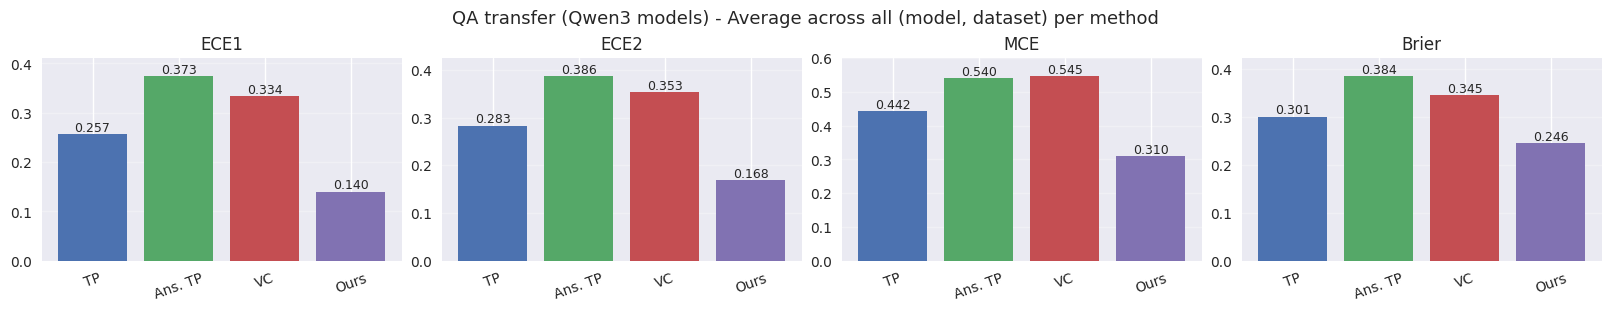

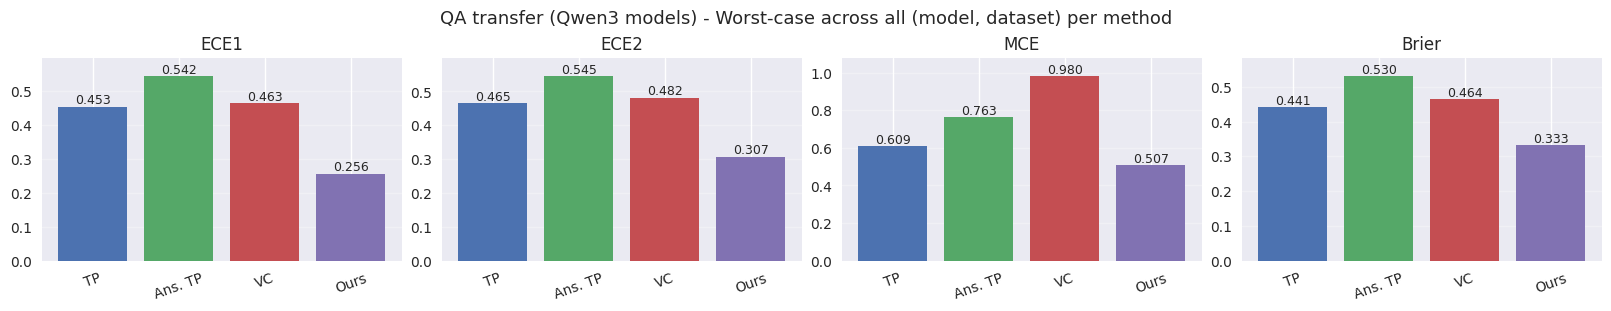

webq_trivia_qa


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.365409,0.380365,0.527834,3.614012,0.375299,0.550128,0.60463
logprob,0.222902,0.264841,0.475897,0.762762,0.271166,0.725329,0.60463
oracle_sc,0.048680,0.059194,0.133666,0.488148,0.149596,0.855470,0.60463
ridge_clip,0.090424,0.113481,0.243217,0.833241,0.210798,0.730499,0.60463
split_isotonic_on_ridge,0.101516,0.113153,0.186242,0.619618,0.211658,0.728534,0.60463
split_isotonic_on_ridge_nrt,0.090535,0.107454,0.192143,0.594780,0.202277,0.750257,0.60463
verbal_conf,0.288189,0.310238,0.610176,1.682518,0.301217,0.714371,0.60463


sciq_trivia_qa


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.365409,0.380365,0.527834,3.614012,0.375299,0.550128,0.60463
logprob,0.222902,0.264841,0.475897,0.762762,0.271166,0.725329,0.60463
oracle_sc,0.048680,0.059194,0.133666,0.488148,0.149596,0.855470,0.60463
ridge_clip,0.115479,0.139688,0.254655,1.026769,0.235954,0.659852,0.60463
split_isotonic_on_ridge,0.086615,0.099929,0.204551,0.651983,0.225797,0.658161,0.60463
split_isotonic_on_ridge_nrt,0.109766,0.124057,0.286670,0.680935,0.240151,0.601688,0.60463
verbal_conf,0.288189,0.310238,0.610176,1.682518,0.301217,0.714371,0.60463


trivia_qa_webq


...

,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.494991,0.503648,0.656752,3.147207,0.490070,0.579422,0.434482
logprob,0.385922,0.395475,0.511012,1.052755,0.389762,0.622803,0.434482
oracle_sc,0.136715,0.165430,0.302083,0.842637,0.244300,0.677441,0.434482
ridge_clip,0.197138,0.228293,0.389553,1.441809,0.288024,0.602403,0.434482
split_isotonic_on_ridge,0.182029,0.196327,0.322864,0.792109,0.275233,0.604579,0.434482
split_isotonic_on_ridge_nrt,0.152249,0.170223,0.300534,0.743386,0.266192,0.609133,0.434482
verbal_conf,0.434116,0.455679,0.623517,2.133595,0.438212,0.641440,0.434482


webq_sciq


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.260031,0.274228,0.434345,1.687535,0.287551,0.586416,0.672417
logprob,0.161858,0.187549,0.339270,0.699456,0.241090,0.652615,0.672417
oracle_sc,0.099741,0.114870,0.194240,0.748189,0.197956,0.716305,0.672417
ridge_clip,0.118627,0.143586,0.257328,0.933676,0.222345,0.670280,0.672417
split_isotonic_on_ridge,0.120439,0.136222,0.226734,0.640181,0.221402,0.667367,0.672417
split_isotonic_on_ridge_nrt,0.146294,0.154498,0.273601,0.637753,0.220670,0.689265,0.672417
verbal_conf,0.278496,0.291876,0.402807,1.396915,0.296818,0.633964,0.672417


trivia_qa_sciq


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.260031,0.274228,0.434345,1.687535,0.287551,0.586416,0.672417
logprob,0.161858,0.187549,0.339270,0.699456,0.241090,0.652615,0.672417
oracle_sc,0.099741,0.114870,0.194240,0.748189,0.197956,0.716305,0.672417
ridge_clip,0.123721,0.153455,0.325248,1.036314,0.226847,0.664215,0.672417
split_isotonic_on_ridge,0.075608,0.097618,0.181121,0.615003,0.211557,0.664137,0.672417
split_isotonic_on_ridge_nrt,0.088948,0.104996,0.221248,0.610179,0.209040,0.674593,0.672417
verbal_conf,0.278496,0.291876,0.402807,1.396915,0.296818,0.633964,0.672417


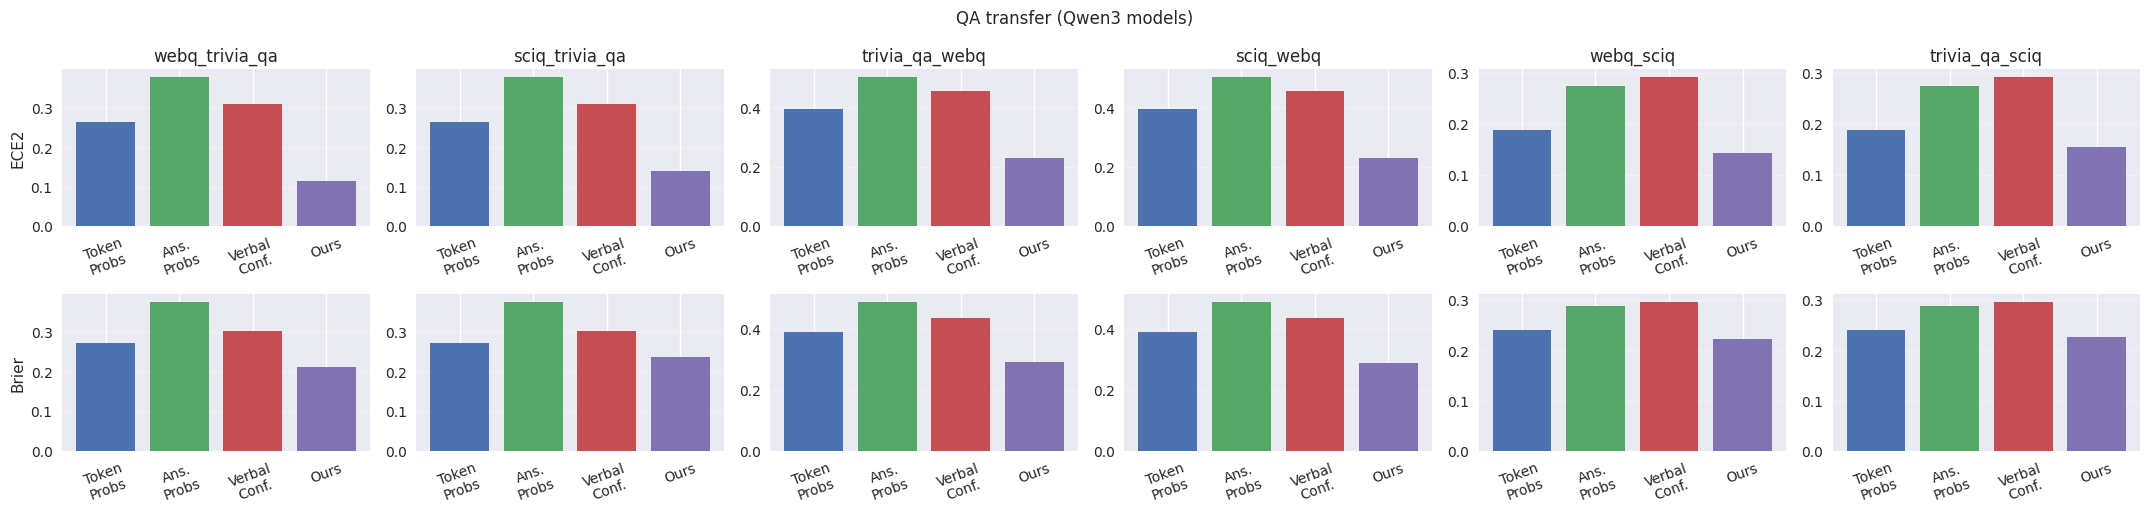

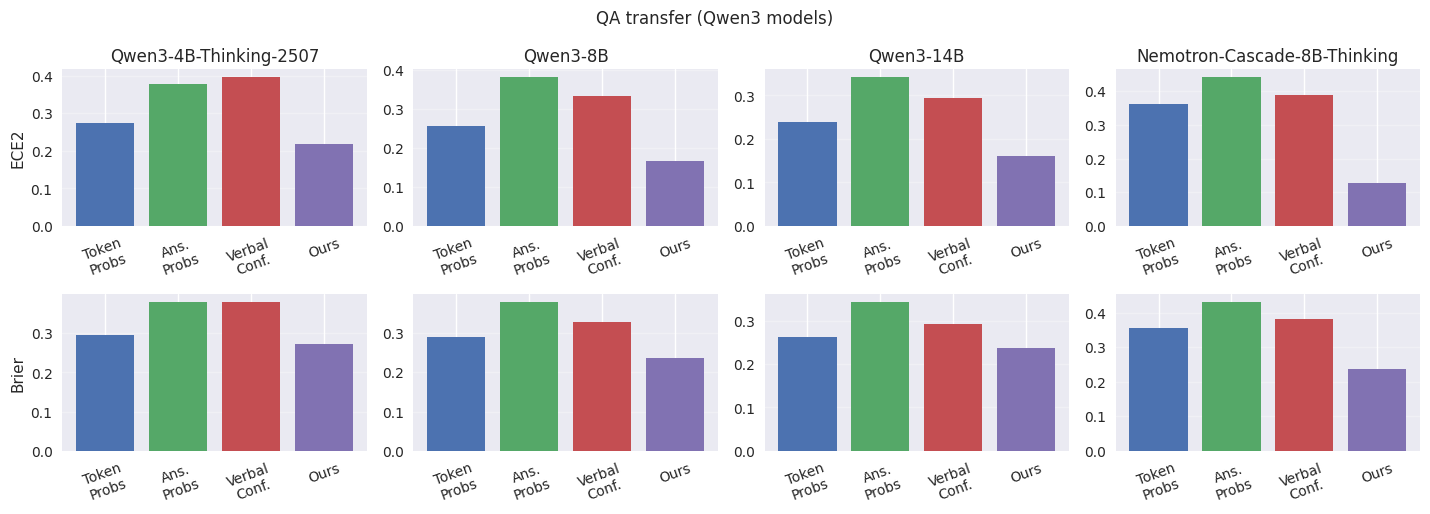

In [5]:
# models = [
#     "Qwen/Qwen3-1.7B", 
#     "Qwen/Qwen3-4B-Thinking-2507", 
#     "Qwen/Qwen3-8B",
#     "Qwen/Qwen3-14B",
#     "nvidia/Nemotron-Cascade-8B-Thinking",
# ]

models = [
    # "Qwen/Qwen3-0.6B", 
    # "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
]

pairs = [
    ["webq", "trivia_qa"],
    ["sciq", "trivia_qa"],
    ["trivia_qa", "webq"],
    ["sciq", "webq"],
    ["webq", "sciq"],
    ["trivia_qa", "sciq"],
]

qa_df = run_pairs_exp(models, pairs, exp_key="qa_transfer", plt_title="QA transfer (Qwen3 models)")

In [6]:
save_qa_df = qa_df[['Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby("Method").mean().reset_index()
save_qa_df["Shift"] = "QA Domain"
save_qa_df = save_qa_df[['Shift', 'Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']]
save_qa_df.to_csv("../results/qa_shift.csv", index=False)
save_qa_df

,Shift,Method,ECE1,ECE2,MCE,Brier,AUROC
0,QA Domain,ans_logprob,0.373477,0.386080,0.539644,0.384307,0.571989
1,QA Domain,logprob,0.256894,0.282622,0.442060,0.300673,0.666915
2,QA Domain,oracle_sc,0.095045,0.113165,0.209996,0.197284,0.749739
3,QA Domain,ridge_clip,0.139832,0.168034,0.309854,0.245765,0.656382
4,QA Domain,split_isotonic_on_ridge,0.115519,0.134381,0.244847,0.234701,0.655346
5,QA Domain,split_isotonic_on_ridge_nrt,0.117958,0.133773,0.259985,0.231870,0.658630
6,QA Domain,verbal_conf,0.333601,0.352598,0.545500,0.345416,0.663258


In [21]:
OUR_METHOD = "split_isotonic_on_ridge_nrt"
comp_methods = ["logprob", "ans_logprob", "verbal_conf", OUR_METHOD]

qa_ds = ["sciq", "trivia_qa", "webq"]

big_qa_df = qa_df[qa_df["Method"].isin(comp_methods)][['Method', 'Dataset', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby(['Dataset', "Method"]).mean().reset_index()
train_datasets = []
test_datasets = []

for label in big_qa_df["Dataset"].tolist():

    for ds in qa_ds:
        if ds in label:
            label = label.replace(ds, DATASETS_MAP[ds])
    train_ds = label.split("_")[0]
    test_ds = label.split("_")[1]
    train_datasets.append(train_ds)
    test_datasets.append(test_ds)

big_qa_df["Train Domain"] = train_datasets
big_qa_df["Test Domain"] = test_datasets
big_qa_df = big_qa_df[['Train Domain', 'Test Domain', 'Method', 'ECE2', 'Brier', 'AUROC']]


big_qa_df["Method"] = pd.Categorical(
    big_qa_df["Method"],
    categories=comp_methods,
    ordered=True,
)

big_qa_df = big_qa_df.sort_values(
    ["Train Domain", "Test Domain", "Method"]
).reset_index(drop=True)

big_qa_df["Method"] = [METHODS_MAP[m] for m in big_qa_df["Method"].tolist()]

big_qa_df

,Train Domain,Test Domain,Method,ECE2,Brier,AUROC
0,SciQ,Trivia QA,Token Probs.,0.264841,0.271166,0.725329
1,SciQ,Trivia QA,Ans. Probs.,0.380365,0.375299,0.550128
2,SciQ,Trivia QA,Verbal Conf.,0.310238,0.301217,0.714371
3,SciQ,Trivia QA,Ours,0.124057,0.240151,0.601688
4,SciQ,WebQ,Token Probs.,0.395475,0.389762,0.622803
5,SciQ,WebQ,Ans. Probs.,0.503648,0.490070,0.579422
6,SciQ,WebQ,Verbal Conf.,0.455679,0.438212,0.641440
7,SciQ,WebQ,Ours,0.170223,0.266192,0.609133
8,Trivia QA,SciQ,Token Probs.,0.187549,0.241090,0.652615
9,Trivia QA,SciQ,Ans. Probs.,0.274228,0.287551,0.586416


In [23]:
print(big_qa_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lllrrr}
\toprule
Train Domain & Test Domain & Method & ECE2 & Brier & AUROC \\
\midrule
SciQ & Trivia QA & Token Probs. & 0.265 & 0.271 & 0.725 \\
SciQ & Trivia QA & Ans. Probs. & 0.380 & 0.375 & 0.550 \\
SciQ & Trivia QA & Verbal Conf. & 0.310 & 0.301 & 0.714 \\
SciQ & Trivia QA & Ours & 0.124 & 0.240 & 0.602 \\
SciQ & WebQ & Token Probs. & 0.395 & 0.390 & 0.623 \\
SciQ & WebQ & Ans. Probs. & 0.504 & 0.490 & 0.579 \\
SciQ & WebQ & Verbal Conf. & 0.456 & 0.438 & 0.641 \\
SciQ & WebQ & Ours & 0.170 & 0.266 & 0.609 \\
Trivia QA & SciQ & Token Probs. & 0.188 & 0.241 & 0.653 \\
Trivia QA & SciQ & Ans. Probs. & 0.274 & 0.288 & 0.586 \\
Trivia QA & SciQ & Verbal Conf. & 0.292 & 0.297 & 0.634 \\
Trivia QA & SciQ & Ours & 0.105 & 0.209 & 0.675 \\
Trivia QA & WebQ & Token Probs. & 0.395 & 0.390 & 0.623 \\
Trivia QA & WebQ & Ans. Probs. & 0.504 & 0.490 & 0.579 \\
Trivia QA & WebQ & Verbal Conf. & 0.456 & 0.438 & 0.641 \\
Trivia QA & WebQ & Ours & 0.141 & 0.253 & 0.627 \\
WebQ & S

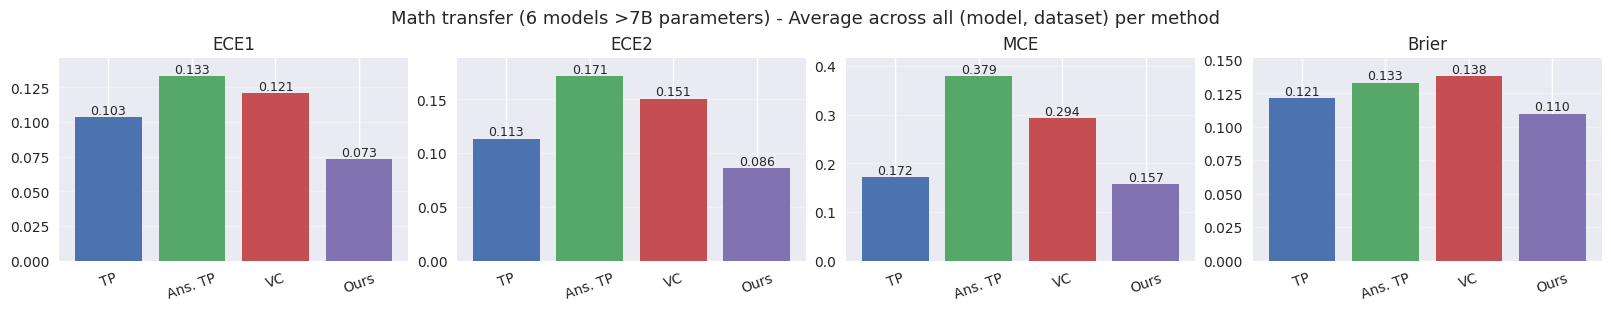

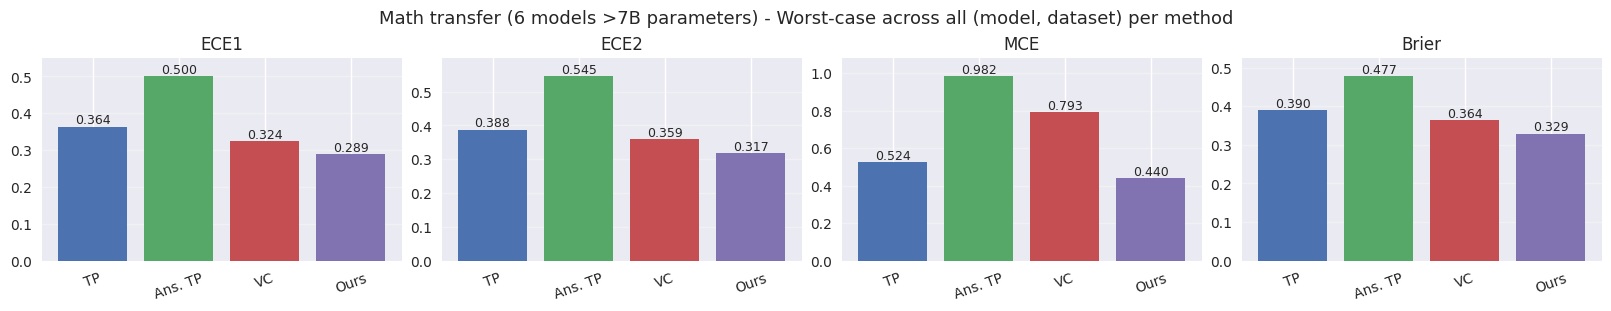

polymath_gsm8k


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.075250,0.091455,0.199221,0.827675,0.076189,0.602717,0.922718
logprob,0.076379,0.082447,0.125439,0.289177,0.077599,0.639983,0.922718
oracle_sc,0.038841,0.051026,0.123974,0.378015,0.058777,0.788259,0.922718
ridge_clip,0.047929,0.057795,0.121079,0.404973,0.071173,0.666089,0.922718
split_isotonic_on_ridge,0.045105,0.056408,0.119504,0.282137,0.070734,0.673028,0.922718
split_isotonic_on_ridge_nrt,0.041449,0.052801,0.105599,0.277996,0.068938,0.693620,0.922718
verbal_conf,0.083431,0.119878,0.289169,0.816982,0.094535,0.630911,0.922718


gsm8k_polymath


,ECE1,ECE2,MCE,NLL,Brier,AUROC,Accuracy
Method,,,,,,,
ans_logprob,0.190669,0.251372,0.558948,1.654835,0.189736,0.744318,0.791821
logprob,0.130274,0.144460,0.219509,0.516775,0.165291,0.640135,0.791821
oracle_sc,0.057490,0.087060,0.216022,0.374461,0.092552,0.877379,0.791821
ridge_clip,0.098584,0.113903,0.193831,0.872871,0.148407,0.670382,0.791821
split_isotonic_on_ridge,0.113544,0.128302,0.234860,0.560648,0.153698,0.668448,0.791821
split_isotonic_on_ridge_nrt,0.123874,0.137895,0.220364,0.559751,0.152416,0.676607,0.791821
verbal_conf,0.158564,0.181262,0.298166,1.507484,0.180822,0.621769,0.791821


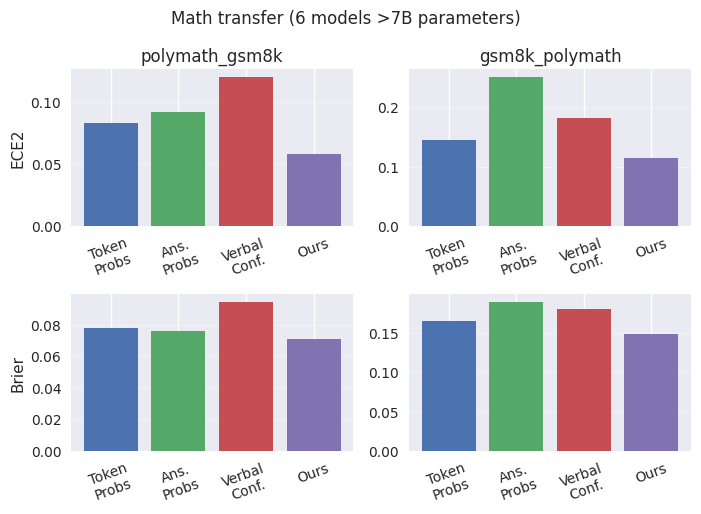

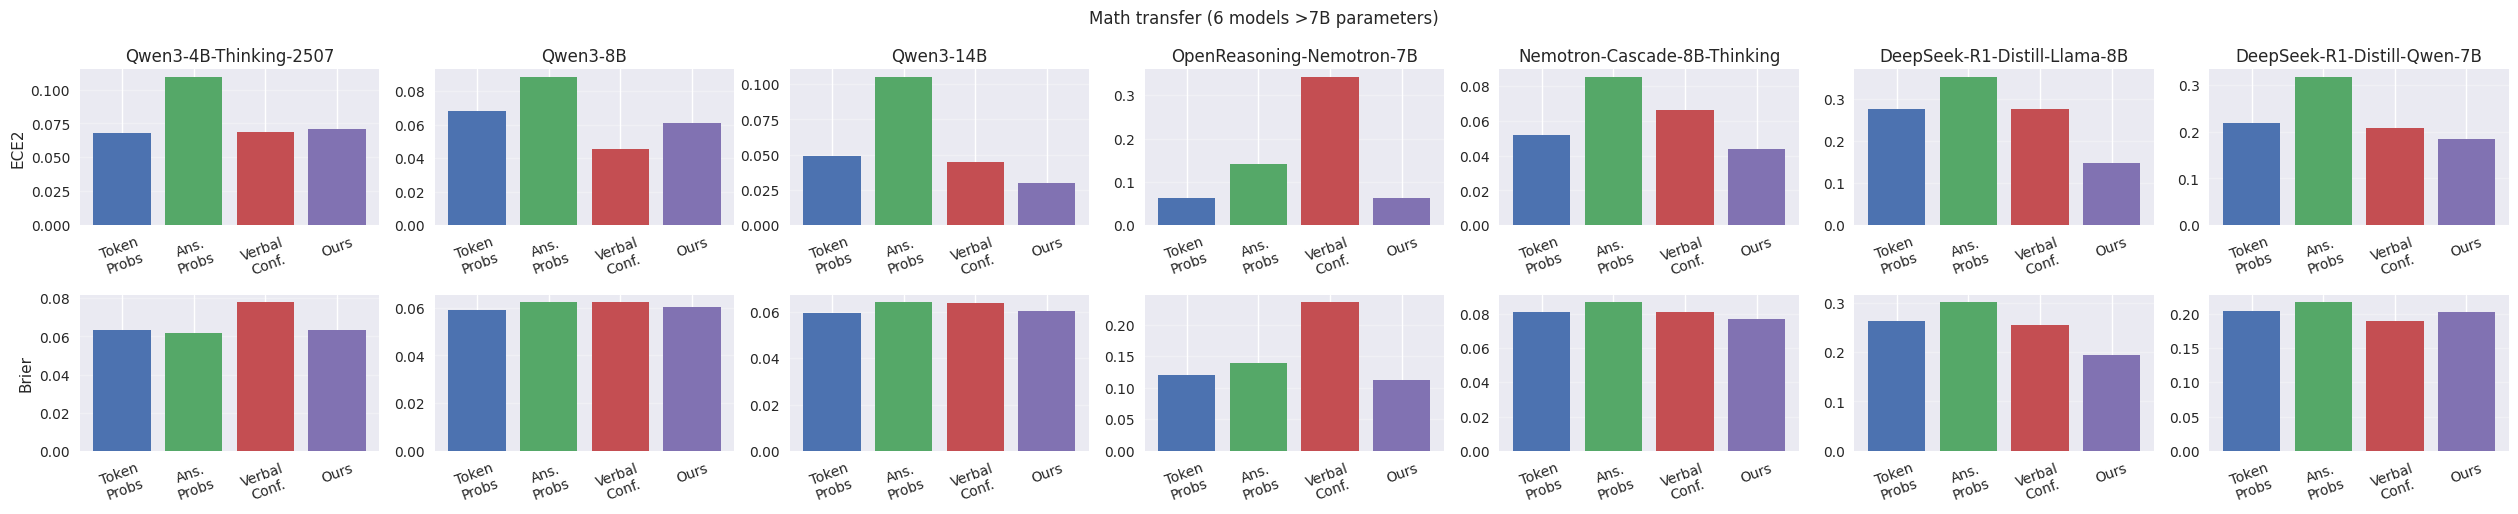

In [8]:
# models = [
#     "Qwen/Qwen3-8B",
#     "Qwen/Qwen3-14B",
#     "nvidia/OpenReasoning-Nemotron-7B",
#     "nvidia/Nemotron-Cascade-8B-Thinking",
#     "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
#     "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
# ]

models = [
    # "Qwen/Qwen3-0.6B", 
    # "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]


pairs = [
    ["polymath", "gsm8k"],
    ["gsm8k", "polymath"],
]

math_df = run_pairs_exp(models, pairs, exp_key="math_transfer", plt_title="Math transfer (6 models >7B parameters)")

In [9]:
save_math_df = math_df[['Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby("Method").mean().reset_index()
save_math_df["Shift"] = "Math Domain"
save_math_df = save_math_df[['Shift', 'Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']]
save_math_df.to_csv("../results/math_shift.csv", index=False)
save_math_df

,Shift,Method,ECE1,ECE2,MCE,Brier,AUROC
0,Math Domain,ans_logprob,0.132959,0.171414,0.379085,0.132963,0.673517
1,Math Domain,logprob,0.103327,0.113454,0.172474,0.121445,0.640059
2,Math Domain,oracle_sc,0.048166,0.069043,0.169998,0.075664,0.832819
3,Math Domain,ridge_clip,0.073257,0.085849,0.157455,0.109790,0.668236
4,Math Domain,split_isotonic_on_ridge,0.079324,0.092355,0.177182,0.112216,0.670738
5,Math Domain,split_isotonic_on_ridge_nrt,0.082661,0.095348,0.162982,0.110677,0.685114
6,Math Domain,verbal_conf,0.120998,0.150570,0.293668,0.137678,0.626340


In [10]:
big_math_df = math_df[['Method', 'Dataset', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby(['Dataset', "Method"]).mean().reset_index()
big_math_df

,Dataset,Method,ECE1,ECE2,MCE,Brier,AUROC
0,gsm8k_polymath,ans_logprob,0.190669,0.251372,0.558948,0.189736,0.744318
1,gsm8k_polymath,logprob,0.130274,0.144460,0.219509,0.165291,0.640135
2,gsm8k_polymath,oracle_sc,0.057490,0.087060,0.216022,0.092552,0.877379
3,gsm8k_polymath,ridge_clip,0.098584,0.113903,0.193831,0.148407,0.670382
4,gsm8k_polymath,split_isotonic_on_ridge,0.113544,0.128302,0.234860,0.153698,0.668448
5,gsm8k_polymath,split_isotonic_on_ridge_nrt,0.123874,0.137895,0.220364,0.152416,0.676607
6,gsm8k_polymath,verbal_conf,0.158564,0.181262,0.298166,0.180822,0.621769
7,polymath_gsm8k,ans_logprob,0.075250,0.091455,0.199221,0.076189,0.602717
8,polymath_gsm8k,logprob,0.076379,0.082447,0.125439,0.077599,0.639983
9,polymath_gsm8k,oracle_sc,0.038841,0.051026,0.123974,0.058777,0.788259


In [27]:
OUR_METHOD = "split_isotonic_on_ridge_nrt"
comp_methods = ["logprob", "ans_logprob", "verbal_conf", OUR_METHOD]

math_ds = ["gsm8k", "polymath"]

big_math_df = math_df[math_df["Method"].isin(comp_methods)][['Method', 'Dataset', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby(['Dataset', "Method"]).mean().reset_index()
train_datasets = []
test_datasets = []

for label in big_math_df["Dataset"].tolist():

    for ds in math_ds:
        if ds in label:
            label = label.replace(ds, DATASETS_MAP[ds])
    train_ds = label.split("_")[0]
    test_ds = label.split("_")[1]
    train_datasets.append(train_ds)
    test_datasets.append(test_ds)

big_math_df["Train Domain"] = train_datasets
big_math_df["Test Domain"] = test_datasets
big_math_df = big_math_df[['Train Domain', 'Test Domain', 'Method', 'ECE2', 'Brier', 'AUROC']]


big_math_df["Method"] = pd.Categorical(
    big_math_df["Method"],
    categories=comp_methods,
    ordered=True,
)

big_math_df = big_math_df.sort_values(
    ["Train Domain", "Test Domain", "Method"]
).reset_index(drop=True)

big_math_df["Method"] = [METHODS_MAP[m] for m in big_math_df["Method"].tolist()]

big_math_df

,Train Domain,Test Domain,Method,ECE2,Brier,AUROC
0,GSM8K,Polymath,Token Probs.,0.144460,0.165291,0.640135
1,GSM8K,Polymath,Ans. Probs.,0.251372,0.189736,0.744318
2,GSM8K,Polymath,Verbal Conf.,0.181262,0.180822,0.621769
3,GSM8K,Polymath,Ours,0.137895,0.152416,0.676607
4,Polymath,GSM8K,Token Probs.,0.082447,0.077599,0.639983
5,Polymath,GSM8K,Ans. Probs.,0.091455,0.076189,0.602717
6,Polymath,GSM8K,Verbal Conf.,0.119878,0.094535,0.630911
7,Polymath,GSM8K,Ours,0.052801,0.068938,0.693620


In [28]:
print(big_math_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lllrrr}
\toprule
Train Domain & Test Domain & Method & ECE2 & Brier & AUROC \\
\midrule
GSM8K & Polymath & Token Probs. & 0.144 & 0.165 & 0.640 \\
GSM8K & Polymath & Ans. Probs. & 0.251 & 0.190 & 0.744 \\
GSM8K & Polymath & Verbal Conf. & 0.181 & 0.181 & 0.622 \\
GSM8K & Polymath & Ours & 0.138 & 0.152 & 0.677 \\
Polymath & GSM8K & Token Probs. & 0.082 & 0.078 & 0.640 \\
Polymath & GSM8K & Ans. Probs. & 0.091 & 0.076 & 0.603 \\
Polymath & GSM8K & Verbal Conf. & 0.120 & 0.095 & 0.631 \\
Polymath & GSM8K & Ours & 0.053 & 0.069 & 0.694 \\
\bottomrule
\end{tabular}

